<a href="https://colab.research.google.com/github/madhu-sudhana07/madhusudhana/blob/main/Netflix_content_recommendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Netflix Movie Recommendation System


In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Loading the dataset
df= pd.read_excel('/content/netflix_titles.xlsx')
df

,duration_minutes,duration_seasons,type,title,date_added,release_year,rating,description,show_id
0,90,NaN,Movie,Norm of the North: King Sized Adventure,2019-09-09 00:00:00,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0
1,94,NaN,Movie,Jandino: Whatever it Takes,2016-09-09 00:00:00,2016.0,TV-MA,Jandino Asporaat riffs on the challenges of ra...,80117401.0
2,NaN,1,TV Show,Transformers Prime,2018-09-08 00:00:00,2013.0,TV-Y7-FV,"With the help of three human allies, the Autob...",70234439.0
3,NaN,1,TV Show,Transformers: Robots in Disguise,2018-09-08 00:00:00,2016.0,TV-Y7,When a prison ship crash unleashes hundreds of...,80058654.0
4,99,NaN,Movie,#realityhigh,2017-09-08 00:00:00,2017.0,TV-14,When nerdy high schooler Dani finally attracts...,80125979.0
...,...,...,...,...,...,...,...,...,...
6231,NaN,13,TV Show,Red vs. Blue,NaN,2015.0,NR,"This parody of first-person shooter games, mil...",80000063.0
6232,NaN,4,TV Show,Maron,NaN,2016.0,TV-MA,"Marc Maron stars as Marc Maron, who interviews...",70286564.0
6233,60,NaN,Movie,Little Baby Bum: Nursery Rhyme Friends,NaN,2016.0,NaN,Nursery rhymes and original music for children...,80116008.0
6234,NaN,2,TV Show,A Young Doctor's Notebook and Other Stories,NaN,2013.0,TV-MA,"Set during the Russian Revolution, this comic ...",70281022.0


In [3]:
df.describe()

,release_year,show_id
count,6.234000e+03,6.232000e+03
mean,1.486502e+04,7.670257e+07
std,1.014711e+06,1.094455e+07
min,1.925000e+03,2.477470e+05
25%,2.013000e+03,8.003569e+07
50%,2.016000e+03,8.016337e+07
75%,2.018000e+03,8.024491e+07
max,8.011919e+07,8.123573e+07


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6236 entries, 0 to 6235
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   duration_minutes  4267 non-null   object 
 1   duration_seasons  1971 non-null   object 
 2   type              6235 non-null   object 
 3   title             6235 non-null   object 
 4   date_added        6223 non-null   object 
 5   release_year      6234 non-null   float64
 6   rating            6223 non-null   object 
 7   description       6233 non-null   object 
 8   show_id           6232 non-null   float64
dtypes: float64(2), object(7)
memory usage: 438.6+ KB


In [5]:
df.isna().sum()

,0
duration_minutes,1969
duration_seasons,4265
type,1
title,1
date_added,13
release_year,2
rating,13
description,3
show_id,4


In [6]:
df.shape

(6236, 9)

In [7]:
df.dtypes

,0
duration_minutes,object
duration_seasons,object
type,object
title,object
date_added,object
release_year,float64
rating,object
description,object
show_id,float64


In [8]:
df.head(2)

,duration_minutes,duration_seasons,type,title,date_added,release_year,rating,description,show_id
0,90,NaN,Movie,Norm of the North: King Sized Adventure,2019-09-09 00:00:00,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0
1,94,NaN,Movie,Jandino: Whatever it Takes,2016-09-09 00:00:00,2016.0,TV-MA,Jandino Asporaat riffs on the challenges of ra...,80117401.0


In [9]:
df['duration_minutes'].unique()

array([90, 94, nan, 99, 110, 60, 78, 95, 58, 62, 65, 61, 135, 98, 96, 79,
       113, 80, 77, 112, 106, 102, 114, 125, 142, 133, 100, 86, 146, 10,
       122, 126, 116, 130, 70, 128, 88, 108, 93, 64, 107, 92, 111, 103,
       40, 85, 72, 45, 89, 24, 127, 163, 117, 42, 104, 75, 82, 38, 97, 81,
       91, 152, 87, 121, 101, 119, 83, 182, 124, 63, 139, 171, 84, 69, 76,
       41, 153, 141, 52, 137, 132, 157, 109, 105, 25, 71, 123, 67, 140,
       138, 149, 47, 68, 148, 54, 151, 155, 162, 28, 160, 29, 57, 46, 73,
       74, 118, 66, 14, 20, 115, 48, 168, 144, 161, 55, 56, 51, 50, 23,
       205, 190, 131, 22, 59, 150, 159, 145, 158, 143, 154, 147, 129, 214,
       136, 134, 44, 156, 30, 120, 209, 166, 200, 185, 36, 11, 53, 165,
       164, 19, 177, 32, 18, 'Flying Fortress"', 170, 187, 173, 12, 3,
       176, 15, 49, 26, 37, 189, 201, 179, 191, 193, 192, 43, 172, 224,
       27, 181, 178, 228, 34, 312, 174, 169, ' and probably will."', 35,
       31, 180, 196, 167, 33, 203, 195], dtype=obj

In [10]:
df['duration_minutes']=pd.to_numeric(df['duration_minutes'], errors ='coerce')

In [11]:
df['duration_minutes'].unique()

array([ 90.,  94.,  nan,  99., 110.,  60.,  78.,  95.,  58.,  62.,  65.,
        61., 135.,  98.,  96.,  79., 113.,  80.,  77., 112., 106., 102.,
       114., 125., 142., 133., 100.,  86., 146.,  10., 122., 126., 116.,
       130.,  70., 128.,  88., 108.,  93.,  64., 107.,  92., 111., 103.,
        40.,  85.,  72.,  45.,  89.,  24., 127., 163., 117.,  42., 104.,
        75.,  82.,  38.,  97.,  81.,  91., 152.,  87., 121., 101., 119.,
        83., 182., 124.,  63., 139., 171.,  84.,  69.,  76.,  41., 153.,
       141.,  52., 137., 132., 157., 109., 105.,  25.,  71., 123.,  67.,
       140., 138., 149.,  47.,  68., 148.,  54., 151., 155., 162.,  28.,
       160.,  29.,  57.,  46.,  73.,  74., 118.,  66.,  14.,  20., 115.,
        48., 168., 144., 161.,  55.,  56.,  51.,  50.,  23., 205., 190.,
       131.,  22.,  59., 150., 159., 145., 158., 143., 154., 147., 129.,
       214., 136., 134.,  44., 156.,  30., 120., 209., 166., 200., 185.,
        36.,  11.,  53., 165., 164.,  19., 177.,  3

In [12]:
df['duration_seasons'].unique()

array([nan, 1, datetime.datetime(2017, 3, 31, 0, 0), 80188902, 2, 5, 3, 7,
       4, 8, 6, 9, 14, 10, 12, 15, 11, 13], dtype=object)

In [13]:
df.duration_seasons = pd.to_numeric(df['duration_seasons'], errors = 'coerce')

In [14]:
df['duration_seasons'].unique()

array([          nan, 1.0000000e+00, 8.0188902e+07, 2.0000000e+00,
       5.0000000e+00, 3.0000000e+00, 7.0000000e+00, 4.0000000e+00,
       8.0000000e+00, 6.0000000e+00, 9.0000000e+00, 1.4000000e+01,
       1.0000000e+01, 1.2000000e+01, 1.5000000e+01, 1.1000000e+01,
       1.3000000e+01])

In [15]:
df.head(2)

,duration_minutes,duration_seasons,type,title,date_added,release_year,rating,description,show_id
0,90.0,NaN,Movie,Norm of the North: King Sized Adventure,2019-09-09 00:00:00,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0
1,94.0,NaN,Movie,Jandino: Whatever it Takes,2016-09-09 00:00:00,2016.0,TV-MA,Jandino Asporaat riffs on the challenges of ra...,80117401.0


In [16]:
df.isna().sum()

,0
duration_minutes,1971
duration_seasons,4266
type,1
title,1
date_added,13
release_year,2
rating,13
description,3
show_id,4


In [17]:
df.shape

(6236, 9)

In [18]:
(df['duration_seasons'].isna().sum()/df.shape[0])*100.0

np.float64(68.40923669018602)

In [19]:
df.drop('duration_seasons',axis = 1, inplace= True)

In [20]:
df.head(2)

,duration_minutes,type,title,date_added,release_year,rating,description,show_id
0,90.0,Movie,Norm of the North: King Sized Adventure,2019-09-09 00:00:00,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0
1,94.0,Movie,Jandino: Whatever it Takes,2016-09-09 00:00:00,2016.0,TV-MA,Jandino Asporaat riffs on the challenges of ra...,80117401.0


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6236 entries, 0 to 6235
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   duration_minutes  4265 non-null   float64
 1   type              6235 non-null   object 
 2   title             6235 non-null   object 
 3   date_added        6223 non-null   object 
 4   release_year      6234 non-null   float64
 5   rating            6223 non-null   object 
 6   description       6233 non-null   object 
 7   show_id           6232 non-null   float64
dtypes: float64(3), object(5)
memory usage: 389.9+ KB


In [22]:
df['duration_minutes'].max()

312.0

In [23]:
df['duration_minutes'].unique()

array([ 90.,  94.,  nan,  99., 110.,  60.,  78.,  95.,  58.,  62.,  65.,
        61., 135.,  98.,  96.,  79., 113.,  80.,  77., 112., 106., 102.,
       114., 125., 142., 133., 100.,  86., 146.,  10., 122., 126., 116.,
       130.,  70., 128.,  88., 108.,  93.,  64., 107.,  92., 111., 103.,
        40.,  85.,  72.,  45.,  89.,  24., 127., 163., 117.,  42., 104.,
        75.,  82.,  38.,  97.,  81.,  91., 152.,  87., 121., 101., 119.,
        83., 182., 124.,  63., 139., 171.,  84.,  69.,  76.,  41., 153.,
       141.,  52., 137., 132., 157., 109., 105.,  25.,  71., 123.,  67.,
       140., 138., 149.,  47.,  68., 148.,  54., 151., 155., 162.,  28.,
       160.,  29.,  57.,  46.,  73.,  74., 118.,  66.,  14.,  20., 115.,
        48., 168., 144., 161.,  55.,  56.,  51.,  50.,  23., 205., 190.,
       131.,  22.,  59., 150., 159., 145., 158., 143., 154., 147., 129.,
       214., 136., 134.,  44., 156.,  30., 120., 209., 166., 200., 185.,
        36.,  11.,  53., 165., 164.,  19., 177.,  3

In [24]:
df[df['duration_minutes'].isna()]

,duration_minutes,type,title,date_added,release_year,rating,description,show_id
2,NaN,TV Show,Transformers Prime,2018-09-08 00:00:00,2013.0,TV-Y7-FV,"With the help of three human allies, the Autob...",70234439.0
3,NaN,TV Show,Transformers: Robots in Disguise,2018-09-08 00:00:00,2016.0,TV-Y7,When a prison ship crash unleashes hundreds of...,80058654.0
5,NaN,TV Show,Apaches,2017-09-08 00:00:00,2016.0,TV-MA,A young journalist is forced into a life of cr...,80163890.0
8,NaN,TV Show,Fire Chasers,2017-09-08 00:00:00,2017.0,TV-MA,"As California's 2016 fire season rages, brave ...",80117902.0
26,NaN,TV Show,Castle of Stars,2018-09-07 00:00:00,2015.0,TV-14,As four couples with different lifestyles go t...,80244601.0
...,...,...,...,...,...,...,...,...
6230,NaN,TV Show,Kikoriki,NaN,2010.0,TV-Y,A wacky rabbit and his gang of animal pals hav...,80159925.0
6231,NaN,TV Show,Red vs. Blue,NaN,2015.0,NR,"This parody of first-person shooter games, mil...",80000063.0
6232,NaN,TV Show,Maron,NaN,2016.0,TV-MA,"Marc Maron stars as Marc Maron, who interviews...",70286564.0
6234,NaN,TV Show,A Young Doctor's Notebook and Other Stories,NaN,2013.0,TV-MA,"Set during the Russian Revolution, this comic ...",70281022.0


In [25]:
df['duration_minutes']=df['duration_minutes'].fillna(0)

In [26]:
df[df['duration_minutes'].isna()]

,duration_minutes,type,title,date_added,release_year,rating,description,show_id


In [27]:
df.isna().sum()

,0
duration_minutes,0
type,1
title,1
date_added,13
release_year,2
rating,13
description,3
show_id,4


In [28]:
df[df['date_added'].isna()]

,duration_minutes,type,title,date_added,release_year,rating,description,show_id
2017,40.0,Movie,The Memphis Belle: A Story of a,NaN,NaN,NaN,NaN,NaN
4525,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6225,0.0,TV Show,Gunslinger Girl,NaN,2008.0,TV-14,"On the surface, the Social Welfare Agency appe...",70204989.0
6226,0.0,TV Show,Anthony Bourdain: Parts Unknown,NaN,2018.0,TV-PG,This CNN original series has chef Anthony Bour...,70304979.0
6227,0.0,TV Show,Frasier,NaN,2003.0,TV-PG,Frasier Crane is a snooty but lovable Seattle ...,70153412.0
6228,0.0,TV Show,La Familia P. Luche,NaN,2012.0,TV-14,"This irreverent sitcom featues Ludovico, Feder...",70243132.0
6229,0.0,TV Show,The Adventures of Figaro Pho,NaN,2015.0,TV-Y7,"Imagine your worst fears, then multiply them: ...",80005756.0
6230,0.0,TV Show,Kikoriki,NaN,2010.0,TV-Y,A wacky rabbit and his gang of animal pals hav...,80159925.0
6231,0.0,TV Show,Red vs. Blue,NaN,2015.0,NR,"This parody of first-person shooter games, mil...",80000063.0
6232,0.0,TV Show,Maron,NaN,2016.0,TV-MA,"Marc Maron stars as Marc Maron, who interviews...",70286564.0


In [29]:
df.groupby('type')['duration_minutes'].median()

,duration_minutes
type,
1944,0.0
Movie,98.0
TV Show,0.0


In [30]:
df[df['type'] == 1944]

,duration_minutes,type,title,date_added,release_year,rating,description,show_id
2018,0.0,1944,TV-PG,This documentary centers on the crew of the B-...,80119194.0,NaN,NaN,NaN


In [31]:
df.loc[2018]

,2018
duration_minutes,0.0
type,1944
title,TV-PG
date_added,This documentary centers on the crew of the B-...
release_year,80119194.0
rating,NaN
description,NaN
show_id,NaN


In [32]:
df.loc[2018, 'release_year'] = df.loc[2018, 'type']

In [33]:
df.loc[2018]

,2018
duration_minutes,0.0
type,1944
title,TV-PG
date_added,This documentary centers on the crew of the B-...
release_year,1944.0
rating,NaN
description,NaN
show_id,NaN


In [35]:
df.loc[2018, 'show_id'] = 80119194.0

In [ ]:
df.loc[2018]

duration_minutes                                                  0.0
type                                                             1944
title                                                           TV-PG
date_added          This documentary centers on the crew of the B-...
release_year                                                   1944.0
rating                                                            NaN
description                                                       NaN
show_id                                                    80119194.0
Name: 2018, dtype: object

In [36]:
df.loc[2018, 'type'] = 'TV Show'

In [37]:
df.loc[2018]

,2018
duration_minutes,0.0
type,TV Show
title,TV-PG
date_added,This documentary centers on the crew of the B-...
release_year,1944.0
rating,NaN
description,NaN
show_id,80119194.0


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6236 entries, 0 to 6235
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   duration_minutes  6236 non-null   float64
 1   type              6235 non-null   object 
 2   title             6235 non-null   object 
 3   date_added        6223 non-null   object 
 4   release_year      6234 non-null   float64
 5   rating            6223 non-null   object 
 6   description       6233 non-null   object 
 7   show_id           6233 non-null   float64
dtypes: float64(3), object(5)
memory usage: 389.9+ KB


In [39]:
df[['release_year', 'show_id' ]]=df[['release_year', 'show_id' ]].astype('Int64')

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6236 entries, 0 to 6235
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   duration_minutes  6236 non-null   float64
 1   type              6235 non-null   object 
 2   title             6235 non-null   object 
 3   date_added        6223 non-null   object 
 4   release_year      6234 non-null   Int64  
 5   rating            6223 non-null   object 
 6   description       6233 non-null   object 
 7   show_id           6233 non-null   Int64  
dtypes: Int64(2), float64(1), object(5)
memory usage: 402.1+ KB


In [41]:
df['duration_minutes'].unique()

array([ 90.,  94.,   0.,  99., 110.,  60.,  78.,  95.,  58.,  62.,  65.,
        61., 135.,  98.,  96.,  79., 113.,  80.,  77., 112., 106., 102.,
       114., 125., 142., 133., 100.,  86., 146.,  10., 122., 126., 116.,
       130.,  70., 128.,  88., 108.,  93.,  64., 107.,  92., 111., 103.,
        40.,  85.,  72.,  45.,  89.,  24., 127., 163., 117.,  42., 104.,
        75.,  82.,  38.,  97.,  81.,  91., 152.,  87., 121., 101., 119.,
        83., 182., 124.,  63., 139., 171.,  84.,  69.,  76.,  41., 153.,
       141.,  52., 137., 132., 157., 109., 105.,  25.,  71., 123.,  67.,
       140., 138., 149.,  47.,  68., 148.,  54., 151., 155., 162.,  28.,
       160.,  29.,  57.,  46.,  73.,  74., 118.,  66.,  14.,  20., 115.,
        48., 168., 144., 161.,  55.,  56.,  51.,  50.,  23., 205., 190.,
       131.,  22.,  59., 150., 159., 145., 158., 143., 154., 147., 129.,
       214., 136., 134.,  44., 156.,  30., 120., 209., 166., 200., 185.,
        36.,  11.,  53., 165., 164.,  19., 177.,  3

In [42]:
df['type'].unique()

array(['Movie', 'TV Show', nan], dtype=object)

In [43]:
df['title'].value_counts(ascending = False).head(60)

,count
title,
The Silence,3
Love,3
Limitless,3
Tunnel,3
Oh My Ghost,3
Tiger,2
The Birth Reborn,2
People You May Know,2
Locked Up,2


In [44]:
df['date_added'].value_counts()

,count
date_added,
2020-01-01 00:00:00,126
2019-11-01 00:00:00,104
2018-03-01 00:00:00,79
2019-12-31 00:00:00,76
2018-10-01 00:00:00,74
...,...
2018-01-28 00:00:00,1
2015-07-18 00:00:00,1
2017-07-19 00:00:00,1


In [45]:
df['date_added']= pd.to_datetime(df['date_added'], errors= 'coerce')

In [46]:
df['date_added'].unique()

<DatetimeArray>
['2019-09-09 00:00:00', '2016-09-09 00:00:00', '2018-09-08 00:00:00',
 '2017-09-08 00:00:00', '2015-09-08 00:00:00', '2018-09-07 00:00:00',
 '2017-09-07 00:00:00', '2019-09-06 00:00:00', '2018-09-06 00:00:00',
 '2017-09-06 00:00:00',
 ...
 '2017-08-02 00:00:00', '2013-08-02 00:00:00', '2016-08-17 00:00:00',
 '2017-08-16 00:00:00', '2018-08-13 00:00:00', '2019-04-28 00:00:00',
 '2017-04-27 00:00:00', '2017-04-23 00:00:00', '2017-04-20 00:00:00',
 '2014-04-01 00:00:00']
Length: 1190, dtype: datetime64[ns]

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6236 entries, 0 to 6235
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   duration_minutes  6236 non-null   float64       
 1   type              6235 non-null   object        
 2   title             6235 non-null   object        
 3   date_added        6222 non-null   datetime64[ns]
 4   release_year      6234 non-null   Int64         
 5   rating            6223 non-null   object        
 6   description       6233 non-null   object        
 7   show_id           6233 non-null   Int64         
dtypes: Int64(2), datetime64[ns](1), float64(1), object(4)
memory usage: 402.1+ KB


In [48]:
df[df['description'].isna()]

,duration_minutes,type,title,date_added,release_year,rating,description,show_id
2017,40.0,Movie,The Memphis Belle: A Story of a,NaT,<NA>,NaN,NaN,<NA>
2018,0.0,TV Show,TV-PG,NaT,1944,NaN,NaN,80119194
4525,0.0,NaN,NaN,NaT,<NA>,NaN,NaN,<NA>


In [49]:
df.dropna(axis =0, how = 'all')

,duration_minutes,type,title,date_added,release_year,rating,description,show_id
0,90.0,Movie,Norm of the North: King Sized Adventure,2019-09-09,2019,TV-PG,Before planning an awesome wedding for his gra...,81145628
1,94.0,Movie,Jandino: Whatever it Takes,2016-09-09,2016,TV-MA,Jandino Asporaat riffs on the challenges of ra...,80117401
2,0.0,TV Show,Transformers Prime,2018-09-08,2013,TV-Y7-FV,"With the help of three human allies, the Autob...",70234439
3,0.0,TV Show,Transformers: Robots in Disguise,2018-09-08,2016,TV-Y7,When a prison ship crash unleashes hundreds of...,80058654
4,99.0,Movie,#realityhigh,2017-09-08,2017,TV-14,When nerdy high schooler Dani finally attracts...,80125979
...,...,...,...,...,...,...,...,...
6231,0.0,TV Show,Red vs. Blue,NaT,2015,NR,"This parody of first-person shooter games, mil...",80000063
6232,0.0,TV Show,Maron,NaT,2016,TV-MA,"Marc Maron stars as Marc Maron, who interviews...",70286564
6233,60.0,Movie,Little Baby Bum: Nursery Rhyme Friends,NaT,2016,NaN,Nursery rhymes and original music for children...,80116008
6234,0.0,TV Show,A Young Doctor's Notebook and Other Stories,NaT,2013,TV-MA,"Set during the Russian Revolution, this comic ...",70281022


In [50]:
df.groupby('type')['duration_minutes'].median()

,duration_minutes
type,
Movie,98.0
TV Show,0.0


In [51]:
df[(df['type']== 'TV Show') & (df['duration_minutes']==0.0)]

,duration_minutes,type,title,date_added,release_year,rating,description,show_id
2,0.0,TV Show,Transformers Prime,2018-09-08,2013,TV-Y7-FV,"With the help of three human allies, the Autob...",70234439
3,0.0,TV Show,Transformers: Robots in Disguise,2018-09-08,2016,TV-Y7,When a prison ship crash unleashes hundreds of...,80058654
5,0.0,TV Show,Apaches,2017-09-08,2016,TV-MA,A young journalist is forced into a life of cr...,80163890
8,0.0,TV Show,Fire Chasers,2017-09-08,2017,TV-MA,"As California's 2016 fire season rages, brave ...",80117902
26,0.0,TV Show,Castle of Stars,2018-09-07,2015,TV-14,As four couples with different lifestyles go t...,80244601
...,...,...,...,...,...,...,...,...
6230,0.0,TV Show,Kikoriki,NaT,2010,TV-Y,A wacky rabbit and his gang of animal pals hav...,80159925
6231,0.0,TV Show,Red vs. Blue,NaT,2015,NR,"This parody of first-person shooter games, mil...",80000063
6232,0.0,TV Show,Maron,NaT,2016,TV-MA,"Marc Maron stars as Marc Maron, who interviews...",70286564
6234,0.0,TV Show,A Young Doctor's Notebook and Other Stories,NaT,2013,TV-MA,"Set during the Russian Revolution, this comic ...",70281022


In [52]:
df['time_diff']=df['date_added'].dt.year - df['release_year']

In [53]:
df

,duration_minutes,type,title,date_added,release_year,rating,description,show_id,time_diff
0,90.0,Movie,Norm of the North: King Sized Adventure,2019-09-09,2019,TV-PG,Before planning an awesome wedding for his gra...,81145628,0.0
1,94.0,Movie,Jandino: Whatever it Takes,2016-09-09,2016,TV-MA,Jandino Asporaat riffs on the challenges of ra...,80117401,0.0
2,0.0,TV Show,Transformers Prime,2018-09-08,2013,TV-Y7-FV,"With the help of three human allies, the Autob...",70234439,5.0
3,0.0,TV Show,Transformers: Robots in Disguise,2018-09-08,2016,TV-Y7,When a prison ship crash unleashes hundreds of...,80058654,2.0
4,99.0,Movie,#realityhigh,2017-09-08,2017,TV-14,When nerdy high schooler Dani finally attracts...,80125979,0.0
...,...,...,...,...,...,...,...,...,...
6231,0.0,TV Show,Red vs. Blue,NaT,2015,NR,"This parody of first-person shooter games, mil...",80000063,<NA>
6232,0.0,TV Show,Maron,NaT,2016,TV-MA,"Marc Maron stars as Marc Maron, who interviews...",70286564,<NA>
6233,60.0,Movie,Little Baby Bum: Nursery Rhyme Friends,NaT,2016,NaN,Nursery rhymes and original music for children...,80116008,<NA>
6234,0.0,TV Show,A Young Doctor's Notebook and Other Stories,NaT,2013,TV-MA,"Set during the Russian Revolution, this comic ...",70281022,<NA>


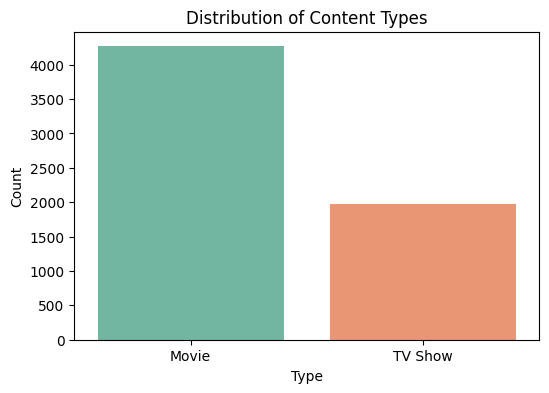

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='type', palette='Set2')
plt.title('Distribution of Content Types')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

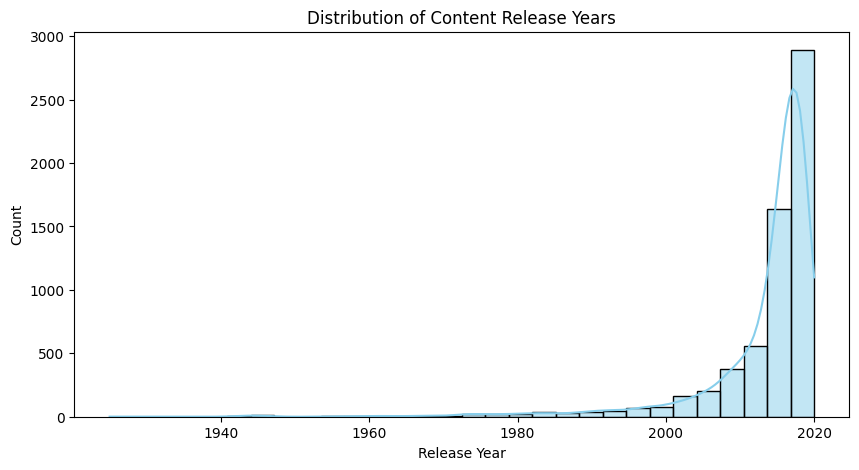

In [59]:
plt.figure(figsize=(10, 5))
# Dropping nulls and converting Int64 to float/int for matplotlib compatibility
sns.histplot(df['release_year'].dropna().astype(int), bins=30, kde=True, color='skyblue')
plt.title('Distribution of Content Release Years')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.show()

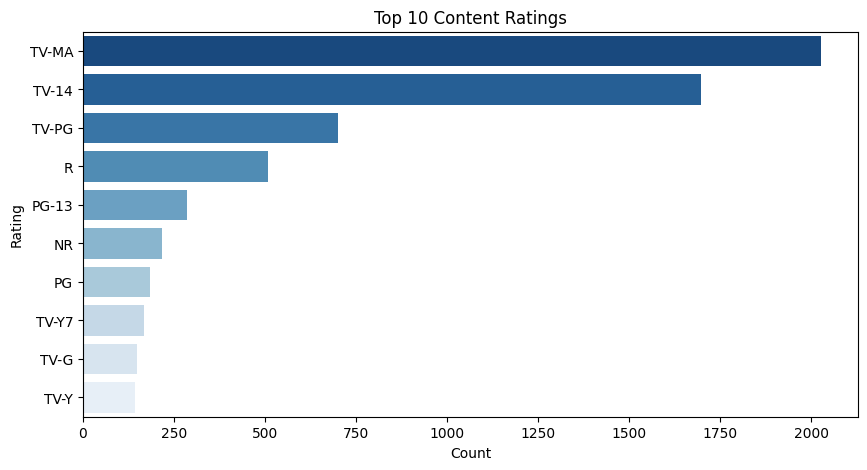

In [60]:
plt.figure(figsize=(10, 5))
top_ratings = df['rating'].value_counts().head(10)
sns.barplot(x=top_ratings.values, y=top_ratings.index, palette='Blues_r')
plt.title('Top 10 Content Ratings')
plt.xlabel('Count')
plt.ylabel('Rating')
plt.show()

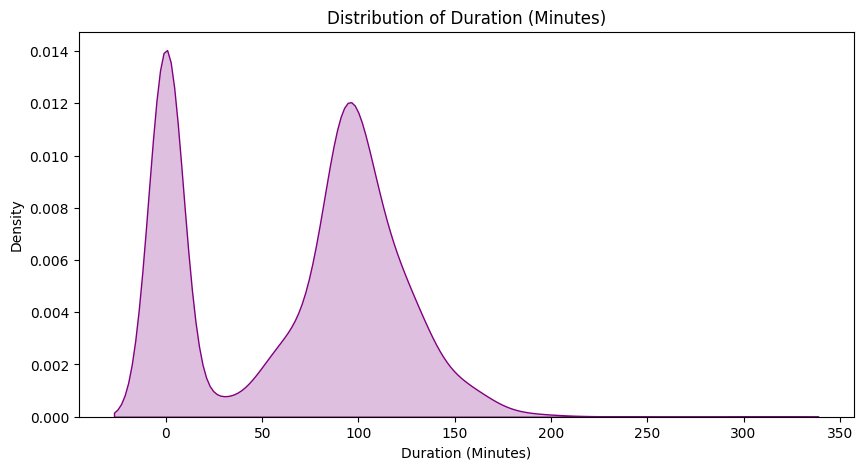

In [61]:
plt.figure(figsize=(10, 5))
sns.kdeplot(df['duration_minutes'].dropna(), fill=True, color='purple')
plt.title('Distribution of Duration (Minutes)')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Density')
plt.show()

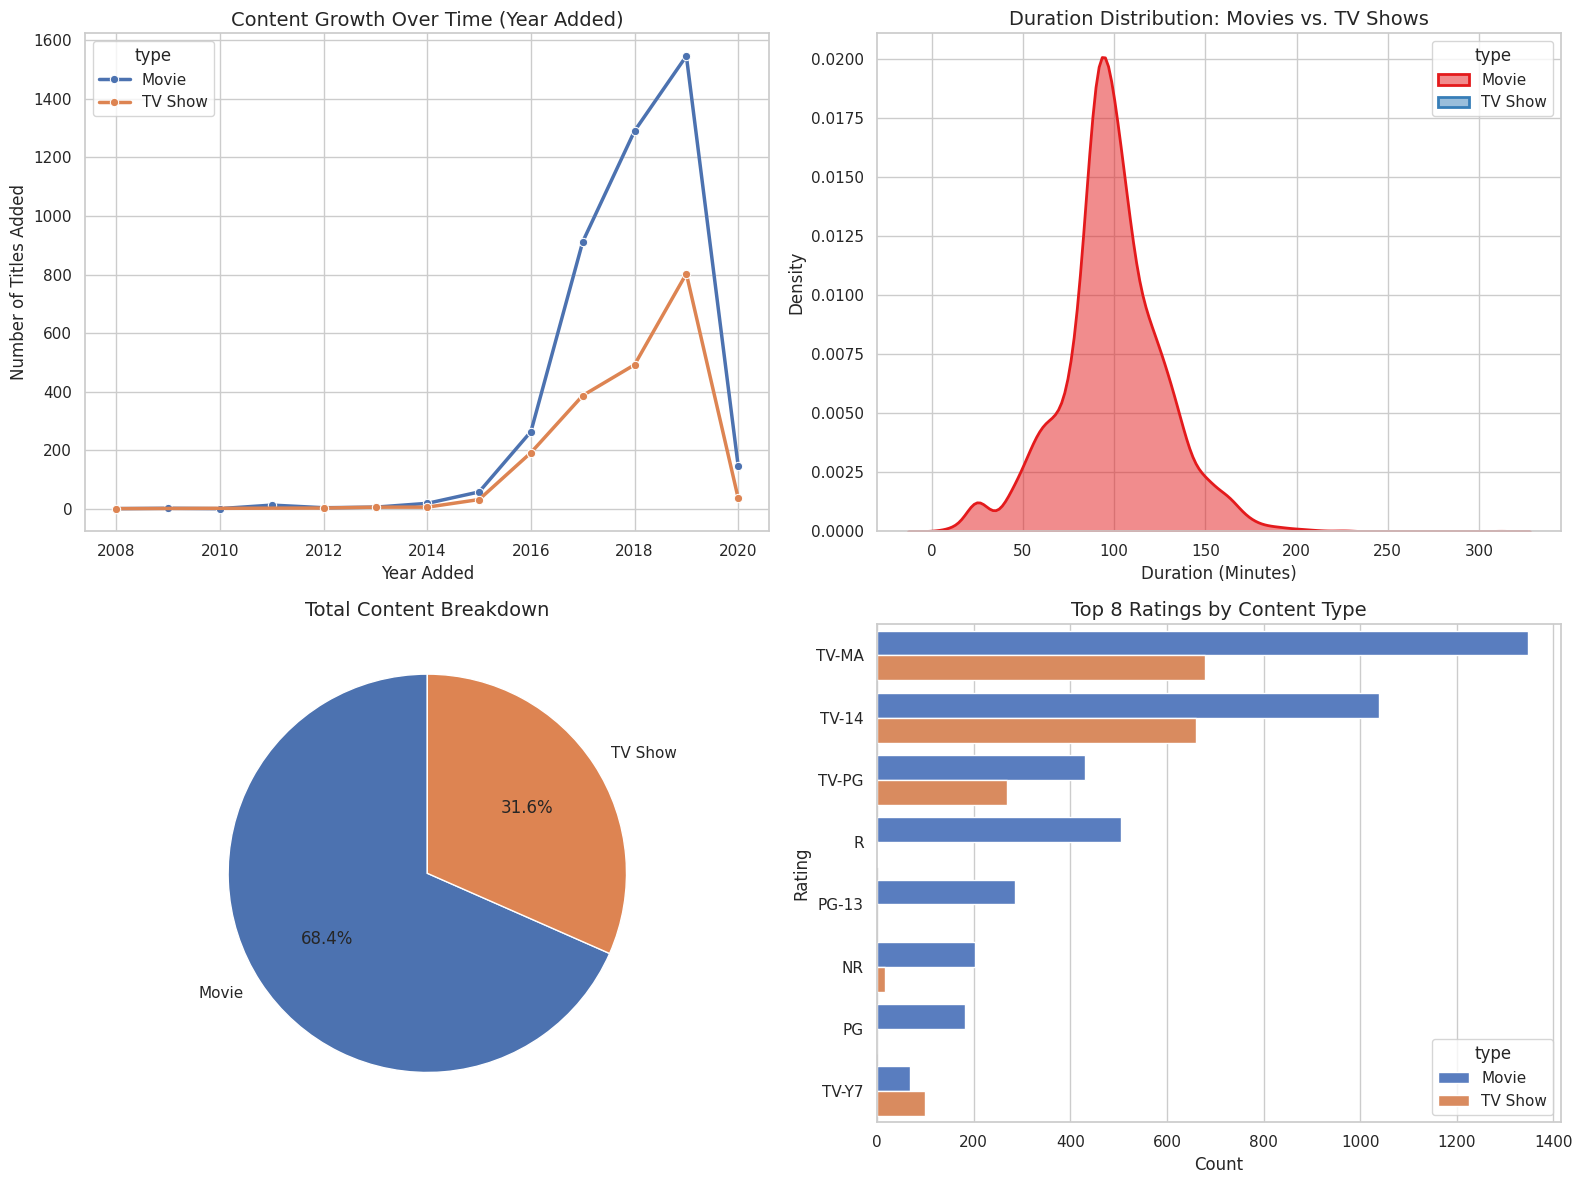

In [62]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Ensure date column is properly recognized
df["date_added"] = pd.to_datetime(df["date_added"])
df["year_added"] = df["date_added"].dt.year

# Set style for clean visual anchors
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Trends Over Time: Content Added Per Year
# --------------------------------------------------
trend_data = (
    df.groupby(["year_added", "type"]).size().reset_index(name="count")
)
sns.lineplot(
    data=trend_data,
    x="year_added",
    y="count",
    hue="type",
    marker="o",
    linewidth=2.5,
    ax=axes[0, 0],
)
axes[0, 0].set_title("Content Growth Over Time (Year Added)", fontsize=14)
axes[0, 0].set_xlabel("Year Added")
axes[0, 0].set_ylabel("Number of Titles Added")

# 2. Separate Durations: Movies vs. TV Shows
# --------------------------------------------------
# Filters out null values for clean plotting
filtered_df = df.dropna(subset=["duration_minutes", "type"])
sns.kdeplot(
    data=filtered_df,
    x="duration_minutes",
    hue="type",
    fill=True,
    common_norm=False,
    palette="Set1",
    alpha=0.5,
    linewidth=2,
    ax=axes[0, 1],
)
axes[0, 1].set_title("Duration Distribution: Movies vs. TV Shows", fontsize=14)
axes[0, 1].set_xlabel("Duration (Minutes)")
axes[0, 1].set_ylabel("Density")

# 3. Content Type Breakdown (Pie Chart)
# --------------------------------------------------
type_counts = df["type"].value_counts()
axes[1, 0].pie(
    type_counts,
    labels=type_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4c72b0", "#dd8452"],
)
axes[1, 0].set_title("Total Content Breakdown", fontsize=14)

# 4. Top Ratings Breakdown by Type
# --------------------------------------------------
top_ratings = df["rating"].value_counts().head(8).index
rating_df = df[df["rating"].isin(top_ratings)]
sns.countplot(
    data=rating_df,
    y="rating",
    hue="type",
    order=top_ratings,
    palette="muted",
    ax=axes[1, 1],
)
axes[1, 1].set_title("Top 8 Ratings by Content Type", fontsize=14)
axes[1, 1].set_xlabel("Count")
axes[1, 1].set_ylabel("Rating")

plt.tight_layout()
plt.show()


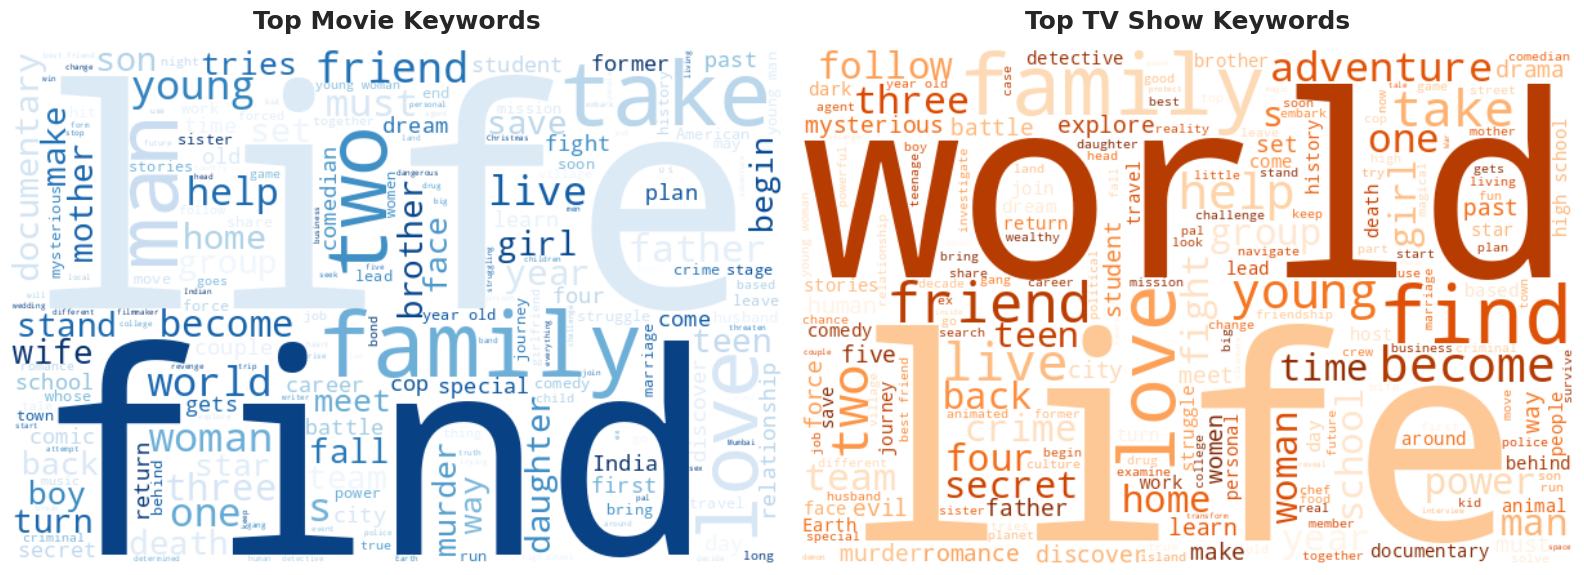

In [66]:
from wordcloud import STOPWORDS, WordCloud

# 1. Separate the descriptions by content type
movie_descriptions = df[df["type"].str.lower() == "movie"]["description"].dropna()
tv_descriptions = df[df["type"].str.lower() == "tv show"]["description"].dropna()

# 2. Combine the descriptions into large text blocks
movie_text = " ".join(movie_descriptions)
tv_text = " ".join(tv_descriptions)

# 3. Create a shared set of custom stopwords to filter out generic streaming words
custom_stopwords = set(STOPWORDS)
# Optional: Add any generic words you want to ignore
custom_stopwords.update(["series", "story", "episode", "season", "movie", "film", "show", "tv", "new"])

# 4. Generate the Word Clouds
movie_wc = WordCloud(
    width=600,
    height=400,
    background_color="white",
    stopwords=custom_stopwords,
    colormap="Blues",
).generate(movie_text)

tv_wc = WordCloud(
    width=600,
    height=400,
    background_color="white",
    stopwords=custom_stopwords,
    colormap="Oranges",
).generate(tv_text)

# 5. Plot the figures side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left Plot: Movies
axes[0].imshow(movie_wc, interpolation="bilinear")
axes[0].set_title("Top Movie Keywords", fontsize=18, fontweight="bold", pad=15)
axes[0].axis("off")

# Right Plot: TV Shows
axes[1].imshow(tv_wc, interpolation="bilinear")
axes[1].set_title("Top TV Show Keywords", fontsize=18, fontweight="bold", pad=15)
axes[1].axis("off")

plt.tight_layout()
plt.show()


In [67]:
import pandas as pd
import sklearn.feature_extraction.text

# Initialize TF-IDF Vectorizer
tfidf = sklearn.feature_extraction.text.TfidfVectorizer(stop_words="english", max_features=20, ngram_range=(1, 2))

# Fit on descriptions
tfidf_matrix = tfidf.fit_transform(df["description"].dropna())

# Get the top overall important keywords across the dataset
importance = tfidf_matrix.sum(axis=0).A1
keywords = tfidf.get_feature_names_out()

tfidf_df = (
    pd.DataFrame({"Keyword": keywords, "Importance": importance})
    .sort_values(by="Importance", ascending=False)
    .head(10)
)
print(tfidf_df)


    Keyword  Importance
8      life  431.325549
19    young  358.219997
12      new  354.602458
17    world  323.248471
1    family  311.325718
11      man  289.829899
10     love  254.357825
4   friends  242.283112
15   series  237.487277
16    woman  235.559131


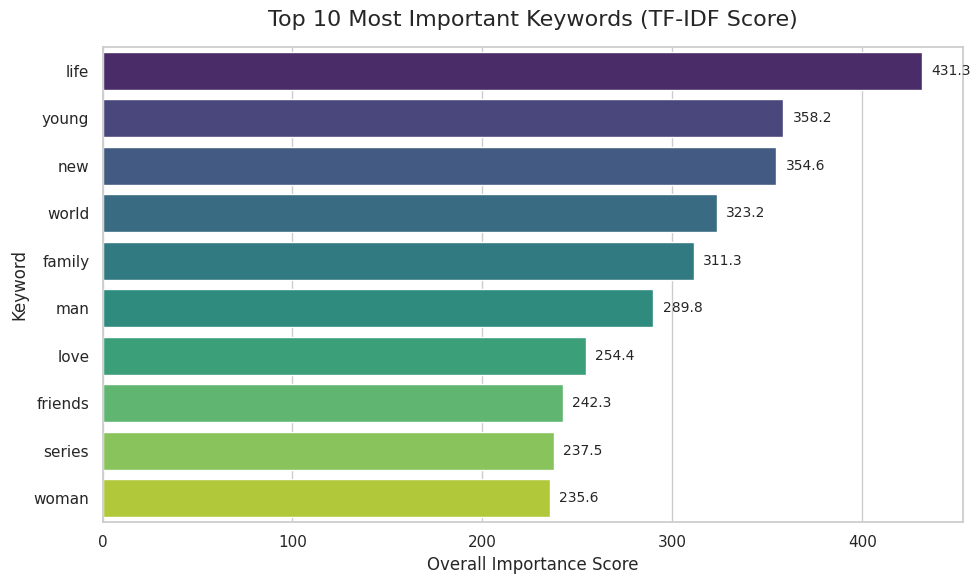

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the horizontal bar chart
plt.figure(figsize=(10, 6))
sns.barplot(
    data=tfidf_df,
    x="Importance",
    y="Keyword",
    palette="viridis",
    hue="Keyword",
    legend=False,
)

# Adding clean titles and labels
plt.title("Top 10 Most Important Keywords (TF-IDF Score)", fontsize=16, pad=15)
plt.xlabel("Overall Importance Score", fontsize=12)
plt.ylabel("Keyword", fontsize=12)

# Displaying the raw scores on top of the bars for scannability
for index, value in enumerate(tfidf_df["Importance"]):
    plt.text(value + 5, index, f"{value:.1f}", va="center", fontsize=10)

plt.tight_layout()
plt.show()


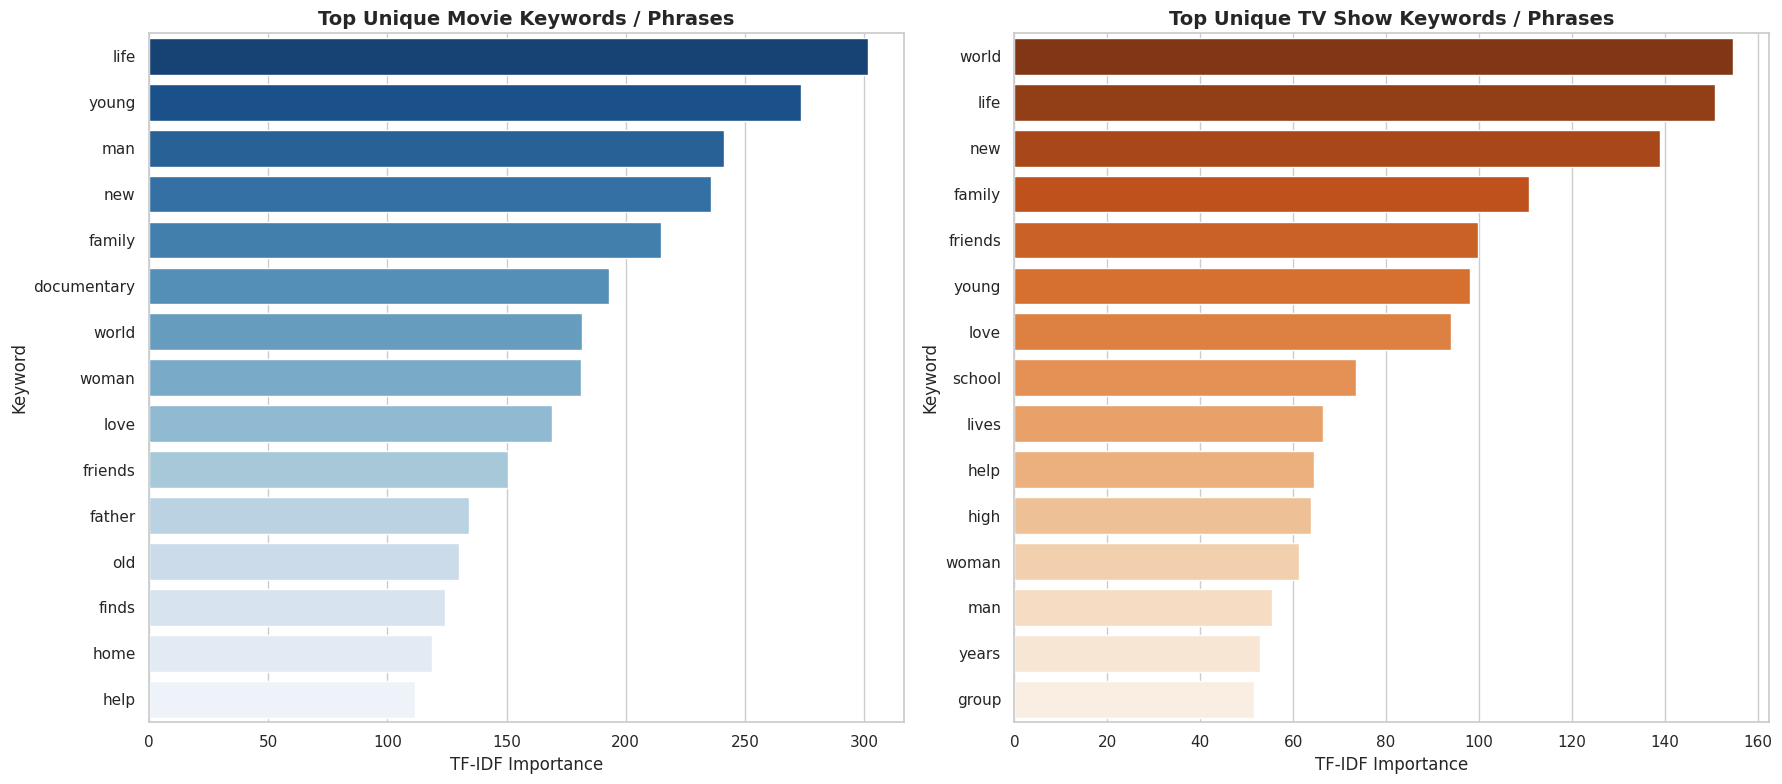

In [69]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns

# Set up the TF-IDF Vectorizer to capture both single words and 2-word phrases
# We add a few structural words like 'series' and 'story' to custom stopwords
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
custom_stopwords = list(ENGLISH_STOP_WORDS) + ['series', 'story', 'season', 'episodes']

tfidf = TfidfVectorizer(stop_words=custom_stopwords, max_features=15, ngram_range=(1, 2))

# 1. Process Movies
movie_desc = df[df['type'].str.lower() == 'movie']['description'].dropna()
movie_matrix = tfidf.fit_transform(movie_desc)
movie_df = pd.DataFrame({
    'Keyword': tfidf.get_feature_names_out(),
    'Importance': movie_matrix.sum(axis=0).A1
}).sort_values(by='Importance', ascending=False)

# 2. Process TV Shows
tv_desc = df[df['type'].str.lower() == 'tv show']['description'].dropna()
tv_matrix = tfidf.fit_transform(tv_desc)
tv_df = pd.DataFrame({
    'Keyword': tfidf.get_feature_names_out(),
    'Importance': tv_matrix.sum(axis=0).A1
}).sort_values(by='Importance', ascending=False)

# 3. Plot side-by-side bar charts
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.barplot(data=movie_df, x='Importance', y='Keyword', palette='Blues_r', ax=axes[0])
axes[0].set_title('Top Unique Movie Keywords / Phrases', fontsize=14, fontweight='bold')
axes[0].set_xlabel('TF-IDF Importance')

sns.barplot(data=tv_df, x='Importance', y='Keyword', palette='Oranges_r', ax=axes[1])
axes[1].set_title('Top Unique TV Show Keywords / Phrases', fontsize=14, fontweight='bold')
axes[1].set_xlabel('TF-IDF Importance')

plt.tight_layout()
plt.show()


In [70]:
def search_content(keyword, content_type=None):
    """
    Searches the dataset for a specific keyword in the description.
    Optional 'content_type' argument: 'Movie' or 'TV Show'.
    """
    # Clean the input keyword
    keyword_clean = str(keyword).lower().strip()

    # Create a copy and handle missing values safely
    search_df = df.dropna(subset=['description', 'title']).copy()

    # Filter by content type if specified
    if content_type:
        search_df = search_df[search_df['type'].str.lower() == content_type.lower()]

    # Search for the term using a regex match (case-insensitive)
    results = search_df[search_df['description'].str.lower().str.contains(r'\b' + keyword_clean + r'\b', regex=True)]

    # Print the clean layout
    print(f"=== Top {min(5, len(results))} matching results for query: '{keyword}' ===\n")
    if results.empty:
        print("No matching descriptions found.")
        return

    for idx, row in results.head(5).iterrows():
        print(f"🎬 Title: {row['title']} ({int(row['release_year']) if not pd.isna(row['release_year']) else 'N/A'})")
        print(f"📌 Type: {row['type']} | ⭐ Rating: {row['rating']}")
        print(f"📝 Description: {row['description']}\n")
        print("-" * 80 + "\n")

# --- HOW TO RUN THE SEARCH FUNCTION ---
# Example 1: Search everything for a phrase
search_content("high school")

# Example 2: Search specifically within Movies
# search_content("secret agent", content_type="Movie")


=== Top 5 matching results for query: 'high school' ===

🎬 Title: Lovesick (2014)
📌 Type: TV Show | ⭐ Rating: TV-14
📝 Description: Love and academics get complicated at an all-male college that happens to be located next to an all-female high school.

--------------------------------------------------------------------------------

🎬 Title: The Politician (2019)
📌 Type: TV Show | ⭐ Rating: TV-14
📝 Description: Rich kid Payton has always known he's going to be president. But first he has to navigate the most treacherous political landscape of all: high school.

--------------------------------------------------------------------------------

🎬 Title: BONDING (2019)
📌 Type: TV Show | ⭐ Rating: TV-MA
📝 Description: A New York City grad student moonlighting as a dominatrix enlists her gay BFF from high school to be her assistant.

--------------------------------------------------------------------------------

🎬 Title: Tall Girl (2019)
📌 Type: Movie | ⭐ Rating: TV-PG
📝 Description: After 

In [71]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


def get_content_recommendations(title_name, df, top_n=5):
    """Recommends titles based on the similarity of their descriptions."""
    # 1. Clean missing values and reset index to match matrix positions safely
    clean_df = df.dropna(subset=["title", "description"]).copy().reset_index(
        drop=True
    )

    # 2. Check if the target title exists in the dataset (case-insensitive)
    title_matches = clean_df[
        clean_df["title"].str.lower() == str(title_name).lower().strip()
    ]

    if title_matches.empty:
        print(f"❌ Error: The title '{title_name}' was not found in the dataset.")
        # Proactively show a few close matches to help the user out
        close_matches = clean_df[
            clean_df["title"].str.lower().str.contains(str(title_name).lower())
        ]["title"].head(3)
        if not close_matches.empty:
            print(f"Did you mean: {', '.join(close_matches)}?")
        return

    # Get the index of the first matching title
    target_idx = title_matches.index[0]
    target_row = clean_df.iloc[target_idx]

    # 3. Vectorize all descriptions using our optimized 1 & 2-word phrase settings
    tfidf = TfidfVectorizer(
        stop_words="english", max_features=5000, ngram_range=(1, 2)
    )
    tfidf_matrix = tfidf.fit_transform(clean_df["description"])

    # 4. Compute Cosine Similarity between the target item and all other items
    # [0] flattens the 2D array output into a 1D array of similarity scores
    similarity_scores = cosine_similarity(
        tfidf_matrix[target_idx], tfidf_matrix
    )[0]

    # 5. Rank the scores and exclude the target movie itself (index 0 in sorted results)
    # argsort returns indices from lowest score to highest score
    similar_indices = similarity_scores.argsort()[::-1]
    similar_indices = [idx for idx in similar_indices if idx != target_idx][
        :top_n
    ]

    # 6. Beautifully print the output
    print(f"⭐ If you liked: '{target_row['title']}' ({int(target_row['release_year'])})")
    print(f"📝 Description: {target_row['description']}\n")
    print(f"🤖 Top {top_n} Recommendations based on shared themes:\n")
    print("=" * 85)

    for rank, idx in enumerate(similar_indices, 1):
        rec_row = clean_df.iloc[idx]
        match_percentage = similarity_scores[idx] * 100
        print(
            f"{rank}. {rec_row['title']} ({int(rec_row['release_year'])}) — [Theme Match: {match_percentage:.1f}%]"
        )
        print(f"   📌 Type: {rec_row['type']} | ⭐ Rating: {rec_row['rating']}")
        print(f"   📝 Summary: {rec_row['description']}")
        print("-" * 85)




In [72]:
# --- HOW TO RUN THE SYSTEM ---
# Simply plug in your dataframe and a title you know is in your dataset
get_content_recommendations("Tall Girl", df)


⭐ If you liked: 'Tall Girl' (2019)
📝 Description: After years of slouching through life, 6-foot-1 teen Jodi resolves to conquer her insecurities and gets caught up in a high school love triangle.

🤖 Top 5 Recommendations based on shared themes:

1. Angel Beats! (2010) — [Theme Match: 41.1%]
   📌 Type: TV Show | ⭐ Rating: TV-14
   📝 Summary: In a high school that's a way station to the afterlife, a teenager gets caught up in the battle for the rights of those in this purgatorial world.
-------------------------------------------------------------------------------------
2. My MVP Valentine (2002) — [Theme Match: 38.0%]
   📌 Type: TV Show | ⭐ Rating: TV-PG
   📝 Summary: An unfortunate accident alters the life of a high school basketball prodigy, who abandons his beloved sport and becomes entangled in a love triangle.
-------------------------------------------------------------------------------------
3. May You Prosper (2017) — [Theme Match: 29.1%]
   📌 Type: Movie | ⭐ Rating: TV-14
   

In [73]:
# Run this once globally to pre-compute relationships
tfidf = TfidfVectorizer(
    stop_words="english", max_features=5000, ngram_range=(1, 2)
)
tfidf_matrix = tfidf.fit_transform(df["description"].fillna(""))
cosine_sim_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)


In [74]:
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import pandas as pd
import seaborn as sns

# 1. Download the required lexicon and initialize the analyzer
nltk.download("vader_lexicon")
sia = SentimentIntensityAnalyzer()


# 2. Function to compute and classify the sentiment scores
def analyze_sentiment(df):
    # Work on a copy to avoid view warnings, fill missing descriptions
    df_sentiment = df.copy()
    df_sentiment["description"] = df_sentiment["description"].fillna("")

    # Extract the 'compound' score which standardizes text from -1 to +1
    df_sentiment["sentiment_score"] = df_sentiment["description"].apply(
        lambda x: sia.polarity_scores(x)["compound"]
    )

    # Classify into simple mood flags
    # We use a slight cushion around 0.05 for neutral/balanced summaries
    def classify_mood(score):
        if score >= 0.15:
            return "Upbeat / Positive"
        elif score <= -0.15:
            return "Dark / Suspenseful"
        else:
            return "Neutral / Balanced"

    df_sentiment["mood_flag"] = df_sentiment["sentiment_score"].apply(
        classify_mood
    )
    return df_sentiment


# Apply analysis to your dataset
df_analyzed = analyze_sentiment(df)

# 3. View sample titles for validation
print("=== Upbeat / Positive Titles Sample ===")
print(
    df_analyzed[df_analyzed["mood_flag"] == "Upbeat / Positive"][
        ["title", "description", "sentiment_score"]
    ].head(3)
)
print("\n" + "=" * 50 + "\n")
print("=== Dark / Suspenseful Titles Sample ===")
print(
    df_analyzed[df_analyzed["mood_flag"] == "Dark / Suspenseful"][
        ["title", "description", "sentiment_score"]
    ].head(3)
)


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


=== Upbeat / Positive Titles Sample ===
                title                                        description  \
2  Transformers Prime  With the help of three human allies, the Autob...   
4        #realityhigh  When nerdy high schooler Dani finally attracts...   
8        Fire Chasers  As California's 2016 fire season rages, brave ...   

   sentiment_score  
2           0.6486  
4           0.5994  
8           0.5719  


=== Dark / Suspenseful Titles Sample ===
                                     title  \
0  Norm of the North: King Sized Adventure   
3         Transformers: Robots in Disguise   
5                                  Apaches   

                                         description  sentiment_score  
0  Before planning an awesome wedding for his gra...          -0.5423  
3  When a prison ship crash unleashes hundreds of...          -0.5267  
5  A young journalist is forced into a life of cr...          -0.2500  


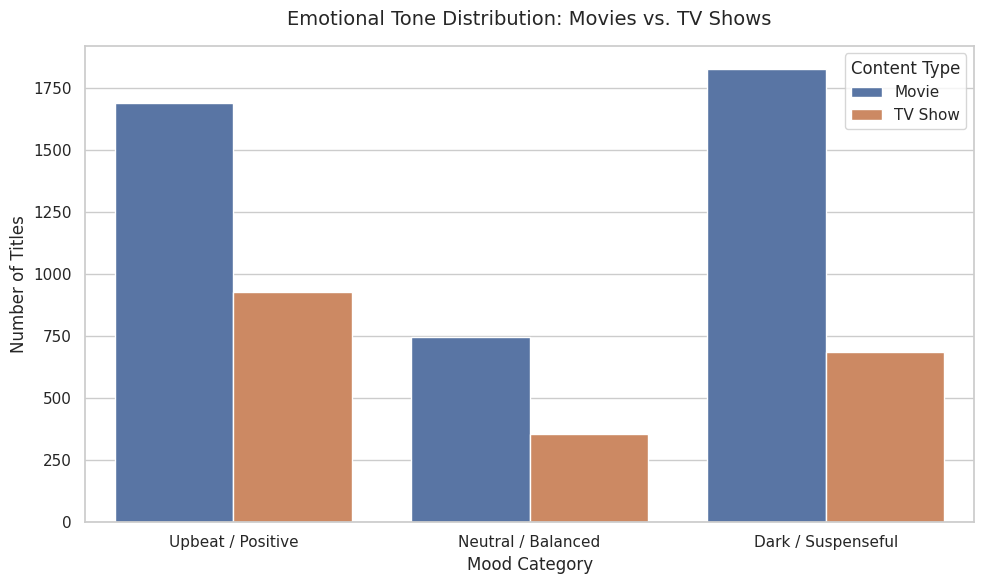

In [75]:
plt.figure(figsize=(10, 6))

# Countplot tracking tone distribution grouped by content type
sns.countplot(
    data=df_analyzed,
    x="mood_flag",
    hue="type",
    palette={"Movie": "#4c72b0", "TV Show": "#dd8452"},
    order=["Upbeat / Positive", "Neutral / Balanced", "Dark / Suspenseful"],
)

plt.title("Emotional Tone Distribution: Movies vs. TV Shows", fontsize=14, pad=15)
plt.xlabel("Mood Category")
plt.ylabel("Number of Titles")
plt.legend(title="Content Type")
plt.tight_layout()
plt.show()


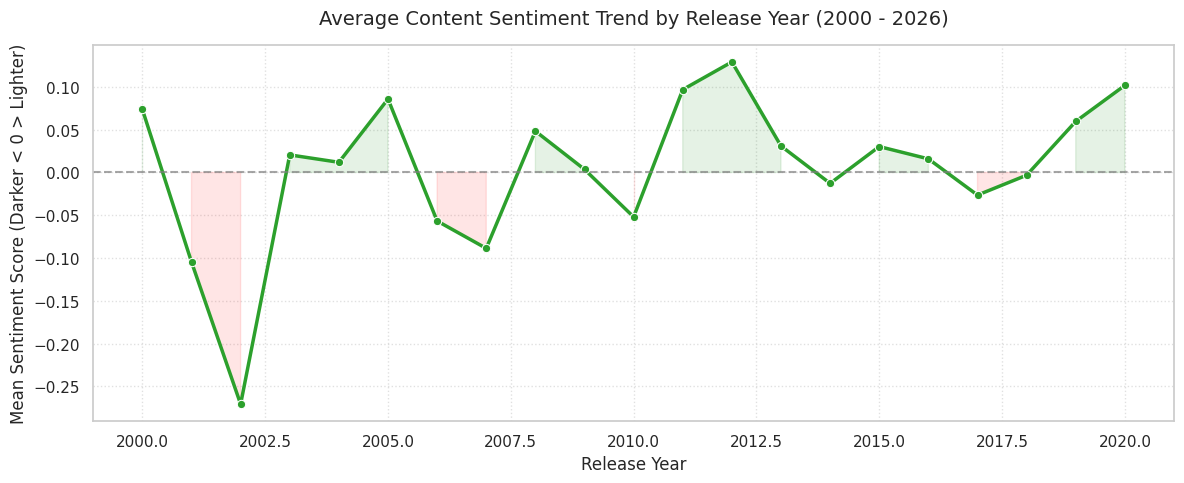

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter data to focus on modern releases for a stable trend (2000-2026)
modern_df = df_analyzed[
    (df_analyzed["release_year"] >= 2000)
    & (df_analyzed["release_year"] <= 2026)
]

# Calculate the mean sentiment per year
yearly_sentiment = (
    modern_df.groupby("release_year")["sentiment_score"].mean().reset_index()
)

# 2. Plot the line trend
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=yearly_sentiment,
    x="release_year",
    y="sentiment_score",
    marker="o",
    color="#2ca02c",
    linewidth=2.5,
)

# Visual anchors/guidelines for interpretation
plt.axhline(
    0, color="gray", linestyle="--", alpha=0.7, label="Perfectly Neutral"
)
plt.fill_between(
    yearly_sentiment["release_year"],
    yearly_sentiment["sentiment_score"],
    0,
    where=(yearly_sentiment["sentiment_score"] > 0),
    color="green",
    alpha=0.1,
)
plt.fill_between(
    yearly_sentiment["release_year"],
    yearly_sentiment["sentiment_score"],
    0,
    where=(yearly_sentiment["sentiment_score"] < 0),
    color="red",
    alpha=0.1,
)

plt.title(
    "Average Content Sentiment Trend by Release Year (2000 - 2026)",
    fontsize=14,
    pad=15,
)
plt.xlabel("Release Year", fontsize=12)
plt.ylabel("Mean Sentiment Score (Darker < 0 > Lighter)", fontsize=12)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()


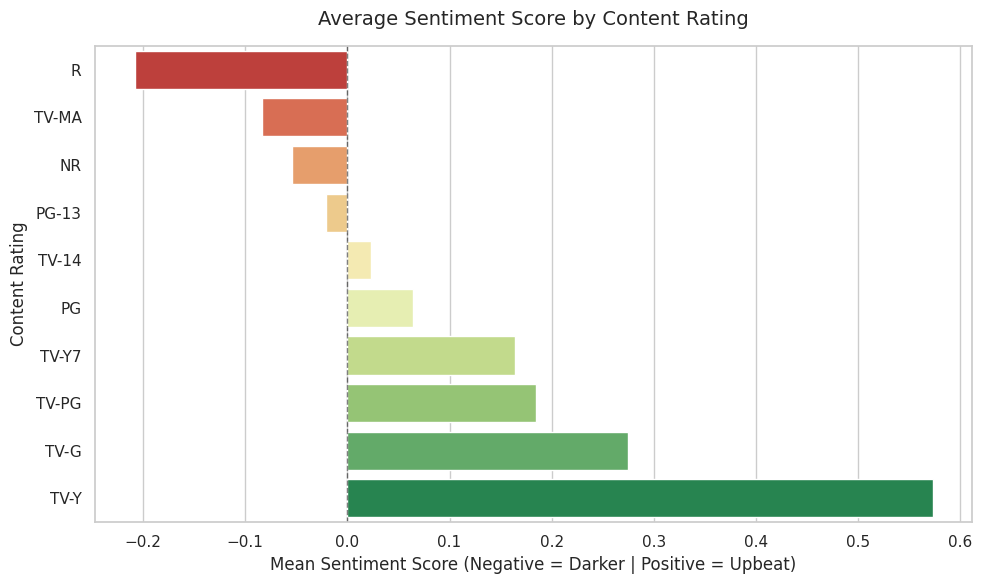

In [77]:
# 1. Identify the top 10 most common content ratings to eliminate noise
top_ratings = df_analyzed["rating"].value_counts().head(10).index
filtered_rating_df = df_analyzed[df_analyzed["rating"].isin(top_ratings)]

# Calculate average sentiment for each rating and sort from darkest to lightest
rating_order = (
    filtered_rating_df.groupby("rating")["sentiment_score"]
    .mean()
    .sort_values()
    .index
)

# 2. Plot the ranking bar chart
plt.figure(figsize=(10, 6))
sns.barplot(
    data=filtered_rating_df,
    y="rating",
    x="sentiment_score",
    order=rating_order,
    palette="RdYlGn",  # Red (Darker/Negative) to Green (Lighter/Positive)
    errorbar=None,
)

# Add a vertical guideline indicating neutral tone balance
plt.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.5)

plt.title("Average Sentiment Score by Content Rating", fontsize=14, pad=15)
plt.xlabel("Mean Sentiment Score (Negative = Darker | Positive = Upbeat)", fontsize=12)
plt.ylabel("Content Rating", fontsize=12)
plt.tight_layout()
plt.show()


In [78]:
import pandas as pd
import seaborn as sns

# 1. Filter out missing values for clean computation
clean_sentiment_df = df_analyzed.dropna(subset=["type", "rating"])

# 2. Generate the multi-variable pivot table
# We look at the count of titles and the average sentiment score simultaneously
mood_pivot = pd.pivot_table(
    clean_sentiment_df,
    values="sentiment_score",
    index=["type", "rating"],
    aggfunc=["count", "mean"],
)

# Rename columns for clear presentation
mood_pivot.columns = ["Total Titles", "Average Sentiment"]

# 3. Filter out rare/uncommon ratings to focus on meaningful trends (e.g., minimum 5 titles)
mood_pivot = mood_pivot[mood_pivot["Total Titles"] >= 5]

# Sort the table from absolute darkest average score to lightest
mood_pivot_sorted = mood_pivot.sort_values(
    by="Average Sentiment", ascending=True
)

# 4. Display the table with a clean color gradient background
# Green indicates upbeat tones, red/yellow highlights darker, intense descriptions
styled_pivot = mood_pivot_sorted.style.background_gradient(
    cmap="RdYlGn", subset=["Average Sentiment"]
).format({"Average Sentiment": "{:.3f}", "Total Titles": "{:,}"})

# If running in a Jupyter Notebook, simply execute:
styled_pivot
# If running a standard .py script, you can print the raw DataFrame directly:
# print(mood_pivot_sorted)


In [79]:
# 1. Sort the dataset to find the lowest possible sentiment scores
# Dropping missing descriptions to avoid sorting errors
darkest_titles = df_analyzed.dropna(subset=['description']).sort_values(
    by='sentiment_score',
    ascending=True
).head(10)

# 2. Print out the full detailed layout
print(f"=== TOP 10 DARKEST / MOST INTENSE SUMMARIES ===\n")
print("=" * 90)

for rank, (idx, row) in enumerate(darkest_titles.iterrows(), 1):
    print(f"🖤 Rank #{rank} | Title: {row['title']} ({int(row['release_year']) if not pd.isna(row['release_year']) else 'N/A'})")
    print(f"📊 Type: {row['type']} | ⭐ Rating: {row['rating']} | 📉 Sentiment Score: {row['sentiment_score']:.4f}")
    print(f"📝 Summary:\n   \"{row['description']}\"")
    print("=" * 90 + "\n")


=== TOP 10 DARKEST / MOST INTENSE SUMMARIES ===

🖤 Rank #1 | Title: A Kind of Murder (2016)
📊 Type: Movie | ⭐ Rating: R | 📉 Sentiment Score: -0.9732
📝 Summary:
   "Obsessed with an unsolved murder case, a crime novelist stuck in an unhappy marriage fantasizes about killing his wife, who soon turns up dead."

🖤 Rank #2 | Title: Soul Eater (2009)
📊 Type: TV Show | ⭐ Rating: TV-14 | 📉 Sentiment Score: -0.9705
📝 Summary:
   "Maka and the other students at the Death Weapon Meister Academy must kill 99 evil humans and one witch, absorbing their spirits when they die."

🖤 Rank #3 | Title: Cut Bank (2014)
📊 Type: Movie | ⭐ Rating: R | 📉 Sentiment Score: -0.9668
📝 Summary:
   "A small-town dreamer is sure he's landed on a gold mine after accidentally filming a murder but is sucked into a violent tale of greed and deception."

🖤 Rank #4 | Title: W/O Ram (2018)
📊 Type: Movie | ⭐ Rating: TV-MA | 📉 Sentiment Score: -0.9648
📝 Summary:
   "Frustrated with the stalled investigation into her husband's 

In [80]:
from collections import Counter
import re
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import pandas as pd

# Ensure dictionary is available
nltk.download("vader_lexicon")
sia = SentimentIntensityAnalyzer()

# 1. Isolate the top 50 darkest summaries
top_50_dark = df_analyzed.dropna(subset=["description"]).sort_values(
    by="sentiment_score", ascending=True
).head(50)

negative_words_found = []

# 2. Loop through summaries to catch individual negative tokens
for desc in top_50_dark["description"]:
    # Clean punctuation and lowercase
    words = re.sub(r"[^\w\s]", "", desc).lower().split()

    for word in words:
        # Check if the individual word has a negative score in VADER
        if sia.polarity_scores(word)["compound"] < 0:
            negative_words_found.append(word)

# 3. Aggregate and display results
neg_counts = Counter(negative_words_found).most_common(15)
neg_word_df = pd.DataFrame(neg_counts, columns=["Negative Word", "Frequency"])

print("=== Top 15 Negative Words Driving the Darkest Scores ===")
print(neg_word_df.to_string(index=False))


=== Top 15 Negative Words Driving the Darkest Scores ===
Negative Word  Frequency
       murder         10
        death          8
       killer          7
       prison          7
      revenge          6
          war          6
         dead          5
        crime          4
         evil          4
      violent          4
    criminals          4
     murdered          4
    terrorist          4
         rape          3
     accident          3


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [81]:
def find_upbeat_adult_content(min_positivity=0.5):
    """
    Filters for R or TV-MA titles that buck the trend
    by carrying highly positive, upbeat descriptions.
    """
    # 1. Filter for target ratings and positive scores
    adult_ratings = ["R", "TV-MA"]
    exceptions_df = df_analyzed[
        (df_analyzed["rating"].isin(adult_ratings)) &
        (df_analyzed["sentiment_score"] >= min_positivity)
    ].sort_values(by="sentiment_score", ascending=False)

    # 2. Print results beautifully
    print(f"=== Found {len(exceptions_df)} Upbeat Exceptions in R/TV-MA Content ===\n")
    print("=" * 90)

    for rank, (idx, row) in enumerate(exceptions_df.head(5).iterrows(), 1):
        print(f"☀️ Exception #{rank} | Title: {row['title']} ({int(row['release_year']) if not pd.isna(row['release_year']) else 'N/A'})")
        print(f"📊 Type: {row['type']} | ⭐ Rating: {row['rating']} | 📈 Sentiment Score: {row['sentiment_score']:.4f}")
        print(f"📝 Summary:\n   \"{row['description']}\"")
        print("=" * 90 + "\n")

# --- HOW TO RUN THE SEARCH ---
find_upbeat_adult_content(min_positivity=0.5)


=== Found 476 Upbeat Exceptions in R/TV-MA Content ===

☀️ Exception #1 | Title: Medal of Honor (2018)
📊 Type: TV Show | ⭐ Rating: TV-MA | 📈 Sentiment Score: 0.9709
📝 Summary:
   "Honoring service members whose courage merited the awarding of a Medal of Honor, this docudrama series re-creates their inspiring true stories."

☀️ Exception #2 | Title: Qué pena tu serie (2015)
📊 Type: TV Show | ⭐ Rating: TV-MA | 📈 Sentiment Score: 0.9657
📝 Summary:
   "Javier is happily in love with Sofia, so when she breaks up their perfect life, he has to get her back – or maybe try finding a new perfect love."

☀️ Exception #3 | Title: Oh, Hello On Broadway (2017)
📊 Type: Movie | ⭐ Rating: TV-MA | 📈 Sentiment Score: 0.9524
📝 Summary:
   "Two delusional geriatrics reveal curious pasts, share a love of tuna and welcome a surprise guest in this filming of the popular Broadway comedy show."

☀️ Exception #4 | Title: College Romance (2018)
📊 Type: TV Show | ⭐ Rating: TV-MA | 📈 Sentiment Score: 0.9403
📝 Summa

In [86]:
from collections import Counter
import re
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import pandas as pd

# Ensure dictionary is available
nltk.download("vader_lexicon")
sia = SentimentIntensityAnalyzer()

# 1. Isolate the top 50 most positive summaries (sort descending)
top_50_positive = df_analyzed.dropna(subset=["description"]).sort_values(
    by="sentiment_score", ascending=False
).head(50)

positive_words_found = []

# 2. Loop through summaries to catch individual positive tokens
for desc in top_50_positive["description"]:
    # Clean punctuation and lowercase
    words = re.sub(r"[^\w\s]", "", desc).lower().split()

    for word in words:
        # Check if the individual word has a positive score in VADER
        if sia.polarity_scores(word)["compound"] > 0:
            positive_words_found.append(word)

# 3. Aggregate and display results
pos_counts = Counter(positive_words_found).most_common(15)
pos_word_df = pd.DataFrame(pos_counts, columns=["Positive Word", "Frequency"])

print("=== Top 15 Positive Words Driving the Brightest Scores ===")
print(pos_word_df.to_string(index=False))

=== Top 15 Positive Words Driving the Brightest Scores ===
Positive Word  Frequency
         love         24
      friends         14
         best         12
         true          8
      romance          7
   adventures          4
         help          4
       chance          4
       comedy          4
      perfect          3
      success          3
       friend          3
   friendship          3
     talented          3
          win          3


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [84]:
import pandas as pd
from scipy import stats

# 1. Clean data to remove rows with missing runtime or sentiment scores
# Filtering out TV Shows since their runtime is structured differently from movies
movie_only_df = df_analyzed[
    (df_analyzed["type"].str.lower() == "movie")
    & df_analyzed["duration_minutes"].notna()
    & df_analyzed["sentiment_score"].notna()
]

# 2. Run the Pearson Correlation Coefficient test
r_score, p_value = stats.pearsonr(
    movie_only_df["duration_minutes"], movie_only_df["sentiment_score"]
)

# 3. Print the statistical results cleanly
print("=== STATISTICAL CORRELATION TEST (MOVIES ONLY) ===")
print(f"📊 Pearson Correlation Coefficient (r): {r_score:.4f}")
print(f"🎯 P-value: {p_value:.4e}")

# 4. Provide a quick interpretation of the data
print("\n🔍 Statistical Interpretation:")
if p_value > 0.05:
    print(
        "❌ There is NO statistically significant relationship between movie runtime and description mood."
    )
else:
    print(
        "✅ The relationship is statistically significant (unlikely to be a fluke)."
    )
    if r_score > 0:
        print(
            f"📈 Positive Correlation: Longer movies tend to have more upbeat descriptions (r = {r_score:.4f})."
        )
    else:
        print(
            f"📉 Negative Correlation: Longer movies tend to have darker/more intense descriptions (r = {r_score:.4f})."
        )

    if abs(r_score) < 0.2:
        print(
            "⚠️ Note: Although statistically significant due to a large dataset, the actual link is VERY WEAK."
        )
    elif abs(r_score) < 0.5:
        print(
            "💡 Note: The link is MODERATE. Runtime plays a notable role in content mood."
        )


=== STATISTICAL CORRELATION TEST (MOVIES ONLY) ===
📊 Pearson Correlation Coefficient (r): -0.0871
🎯 P-value: 1.2036e-08

🔍 Statistical Interpretation:
✅ The relationship is statistically significant (unlikely to be a fluke).
📉 Negative Correlation: Longer movies tend to have darker/more intense descriptions (r = -0.0871).
⚠️ Note: Although statistically significant due to a large dataset, the actual link is VERY WEAK.


In [88]:
import ipywidgets as widgets
from IPython.display import HTML, display
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ---------------------------------------------------------
# 1. Data Preprocessing & Model Setup
# ---------------------------------------------------------
# Filter out records missing title, description, or type
df_rec = (
    df.dropna(subset=['title', 'description', 'type'])
    .drop_duplicates(subset=['title'])
    .reset_index(drop=True)
)

# FORCE titles to be strings to prevent sorting errors with inferred datetimes
df_rec['title'] = df_rec['title'].astype(str)

# Compute TF-IDF matrix using descriptions
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df_rec['description'])

# Quick lookup mappings
title_to_idx = {title: idx for idx, title in enumerate(df_rec['title'])}

# ---------------------------------------------------------
# 2. Recommendation Logic
# ---------------------------------------------------------
def get_top_recommendations(watched_title, target_type='Any', top_n=5):
  if watched_title not in title_to_idx:
    return pd.DataFrame()

  idx = title_to_idx[watched_title]
  sim_scores = list(
      enumerate(cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten())
  )
  sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

  recommendations = []
  for item_idx, score in sim_scores:
    if item_idx == idx:
      continue

    row = df_rec.iloc[item_idx]
    if target_type != 'Any' and row['type'] != target_type:
      continue

    recommendations.append({
        'Title': row['title'],
        'Type': row['type'],
        'Release Year': row.get('release_year', 'N/A'),
        'Rating': row.get('rating', 'N/A'),
        'Match Similarity': f'{score * 100:.1f}%',
        'Description': row['description'],
    })

    if len(recommendations) == top_n:
      break

  return pd.DataFrame(recommendations)


# ---------------------------------------------------------
# 3. Interactive UI Widgets
# ---------------------------------------------------------
# Watched content type selection
watched_type_dd = widgets.Dropdown(
    options=['Movie', 'TV Show'],
    value='Movie',
    description='Watched Type:',
    style={'description_width': '130px'},
    layout=widgets.Layout(width='400px'),
)

# Dynamically populated title dropdown
initial_titles = sorted(
    df_rec[df_rec['type'] == 'Movie']['title'].dropna().unique()
)
watched_title_dd = widgets.Dropdown(
    options=initial_titles,
    value=initial_titles[0] if initial_titles else None,
    description='Watched Title:',
    style={'description_width': '130px'},
    layout=widgets.Layout(width='550px'),
)

# Target recommendation type
target_type_dd = widgets.Dropdown(
    options=['Movie', 'TV Show', 'Any'],
    value='Movie',
    description='Recommend Type:',
    style={'description_width': '130px'},
    layout=widgets.Layout(width='400px'),
)

recommend_btn = widgets.Button(
    description='Get Top 5 Recommendations',
    button_style='primary',
    icon='film',
    layout=widgets.Layout(width='260px', margin='10px 0 0 135px'),
)

output_area = widgets.Output()

# ---------------------------------------------------------
# 4. Event Handlers & Observers
# ---------------------------------------------------------
def on_watched_type_change(change):
  """Updates title dropdown when user switches between Movie and TV Show."""
  selected_type = change['new']
  titles = sorted(
      df_rec[df_rec['type'] == selected_type]['title'].dropna().unique()
  )
  watched_title_dd.options = titles
  if titles:
    watched_title_dd.value = titles[0]


watched_type_dd.observe(on_watched_type_change, names='value')


def on_button_click(b):
  """Computes and renders the top 5 matches upon button click."""
  with output_area:
    output_area.clear_output()
    selected_title = watched_title_dd.value
    target_type = target_type_dd.value

    recs_df = get_top_recommendations(
        selected_title, target_type=target_type, top_n=5
    )

    if recs_df.empty:
      display(HTML("<p style='color: red;'>No matches found.</p>"))
    else:
      target_label = target_type if target_type != 'Any' else 'Title'
      display(
          HTML(
              f"<h4 style='margin-top:15px;'>Top 5 {target_label}"
              f" Recommendations Based On: <i>{selected_title}</i></h4>"
          )
      )
      display(
          HTML(
              recs_df.to_html(
                  index=False,
                  classes='table table-bordered table-hover',
                  justify='left',
              )
          )
      )


recommend_btn.on_click(on_button_click)

# ---------------------------------------------------------
# 5. Render Widget Interface
# ---------------------------------------------------------
ui = widgets.VBox([
    widgets.HTML('<h3>Netflix Content Recommendation Engine</h3>'),
    watched_type_dd,
    watched_title_dd,
    target_type_dd,
    recommend_btn,
    output_area,
])

display(ui)